In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

In [24]:
fc2_embeddings = np.load("output/fc2_embeddings.npy")
scores = np.load("output/score_values.npy")
full_embeddings = np.load("output/embeddings.npy")
ground_truth = np.load('output/ground_truth.npy')

np.unique(ground_truth, return_counts=True)

(array([0., 1.]), array([2156,  180]))

In [48]:
roc_auc_score(ground_truth, scores)

print(f1_score(ground_truth, scores >= 0.5))
accuracy_score(ground_truth, (scores >= 0.5))

0.504930966469428


0.8925513698630136

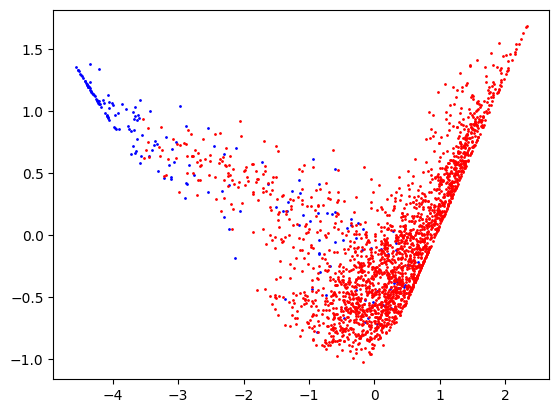

In [12]:
model = PCA(n_components=2)
pred = model.fit_transform(fc2_embeddings)

positive_sites = np.argwhere(ground_truth > 0.5)
negative_sites = np.argwhere(ground_truth <= 0.5)

plt.scatter(pred[positive_sites, 0], pred[positive_sites, 1], c='b', s=1)
plt.scatter(pred[negative_sites, 0], pred[negative_sites, 1], c='r', s=1)

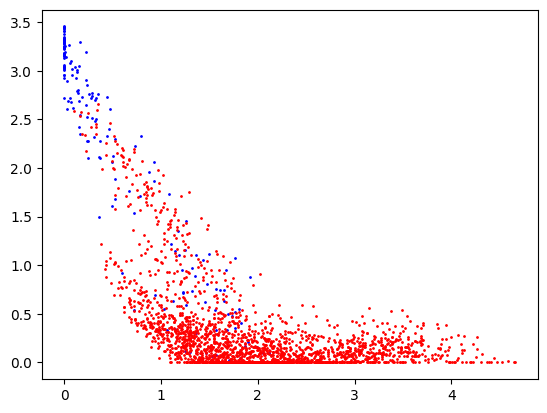

In [13]:
plt.scatter(fc2_embeddings[positive_sites, 1], fc2_embeddings[positive_sites, 2], s=1, c="b")
plt.scatter(fc2_embeddings[negative_sites, 1], fc2_embeddings[negative_sites, 2], s=1, c="r")


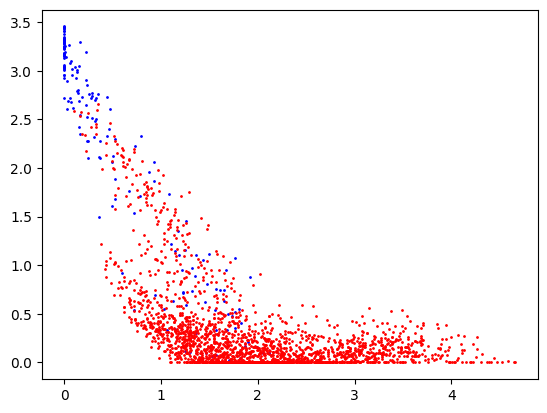

In [14]:
plt.scatter(fc2_embeddings[positive_sites, 1], fc2_embeddings[positive_sites, 2], s=1, c="b")
plt.scatter(fc2_embeddings[negative_sites, 1], fc2_embeddings[negative_sites, 2], s=1, c="r")



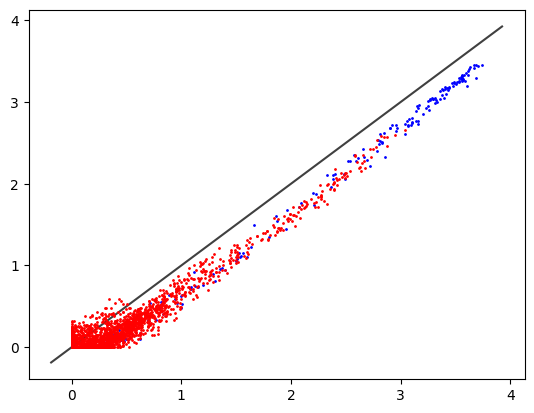

In [15]:
fig, ax = plt.subplots()

plt.scatter(fc2_embeddings[positive_sites, 0], fc2_embeddings[positive_sites, 2], s=1, c="b")
plt.scatter(fc2_embeddings[negative_sites, 0], fc2_embeddings[negative_sites, 2], s=1, c="r")

lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]

# now plot both limits against eachother
plt.plot(lims, lims, 'k-', alpha=0.75, zorder=0)

<StemContainer object of 3 artists>

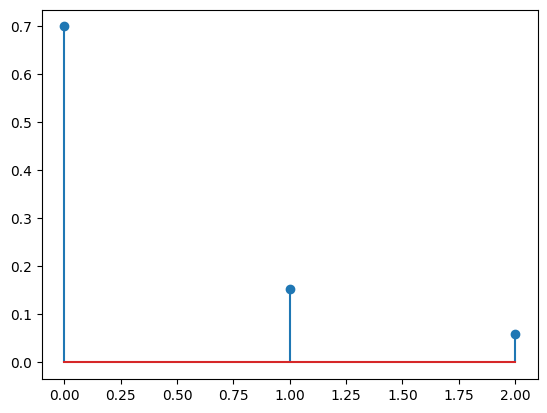

In [16]:
model = PCA(n_components=3)
pred = model.fit_transform(full_embeddings)
plt.stem(model.explained_variance_ratio_)

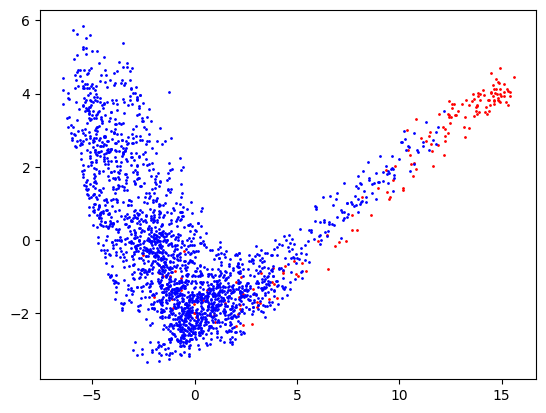

In [20]:
plt.scatter(pred[positive_sites, 0], pred[positive_sites, 1], c='r', s=1)
plt.scatter(pred[negative_sites, 0], pred[negative_sites, 1], c='b', s=1)

[14 22 24 27 21 17 18 39 59 41 37  2  5  6 33 31 19 16 13 15 30 28 56  7
  8 11 34 20 55 25 32 48 10 52  0  3 43 53 57 12 54 35  1 50  4 58 49 26
 23 29 44 51 38 47 36 40 45 42 46  9]


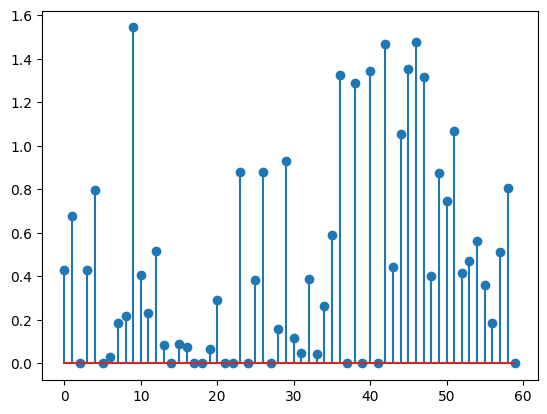

In [21]:
plt.stem(np.std(full_embeddings, axis=0))
print(np.std(full_embeddings, axis=0).argsort())

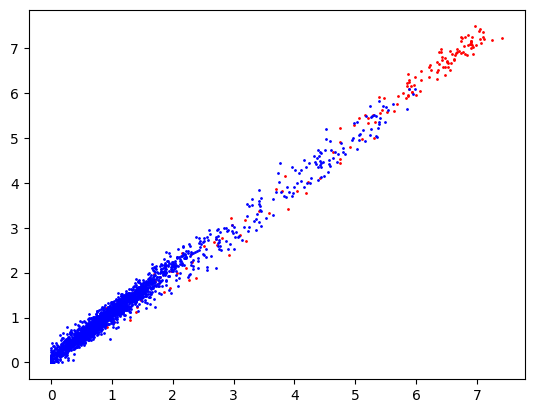

In [22]:
plt.scatter(full_embeddings[positive_sites, 42], full_embeddings[positive_sites, 46], c='r', s=1)
plt.scatter(full_embeddings[negative_sites, 42], full_embeddings[negative_sites, 46], c='b', s=1)